In [1]:
# -*- coding: utf-8 -*-
"""
Created on 2023-01-01
Revised on 2026-04-03

@author:       Oscar Trevizo
@institution:  Harvard Extension School — Graduate Data Science Program (2023)
@context:      Independent project — toolbox vignette, R to Python (_r2p)
@environment:  Python 3.14.3 | myenv | MacBook Air M5

Dataset Simulations: 2D and 3D — Toolbox Vignette (_r2p)
=========================================================

Purpose:
    Canonical dataset simulation functions for 2D and 3D classification
    problems. These are the reference generators used across the
    machine_learning/ notebooks, particularly:
      - neural_networks_2d_3d_datasets_ISLR_Ch10.ipynb
      - multivar_logistic_reg_LDA_QDA_classification_ISLR_Ch4.ipynb
      - univar_logistic_reg_LDA_QDA_classification_ISLR_Ch4.ipynb

    Four datasets of increasing complexity:
      1. 2D, 1 center,  1 category — baseline Gaussian cloud
      2. 2D, 2 centers, 2 categories — linearly separable side-by-side
      3. 2D, 4 centers, 2 categories — XOR-like, non-linearly separable
      4. 3D, 1 center,  2 categories — inside/outside a cube boundary

    Provides:
      - Four standalone generator functions with full docstrings
      - DatasetSimulator convenience class (wraps all four)
      - draw_cube_wireframe() 3D visualization helper
      - Harvard color palette

    R equivalent: simulate_2d_3d_datasets.Rmd
    R libraries:  scatterplot3d
    Python libs:  numpy, pandas, matplotlib, mpl_toolkits.mplot3d

    Suffix _r2p: This notebook was converted from R to Python.

    Note on ctr_positions:
      This toolbox uses ctr_positions=3 (wider separation than the NN
      notebook which uses 1) for cleaner visualization of the generators.

    Credit: Dataset designs based on Harvard Statistical Learning class
    by Dr. Andrey Sivachenko and Dr. Victor A. Farutin.
    cubedraw() based on Martin Maechler's scatterplot3d example.

Revision History:
    2023-01-01  Original R development
                - R script: simulate_2d_3d_datasets.Rmd
                - bld_3d_2c() and cubedraw() R functions

    2026-04-03  Converted to Python / Jupyter Notebook (_r2p)
                - bld_3d_2c() → build_3d_2class()
                - cubedraw() → draw_cube_wireframe()
                - Added: build_2d_1class(), build_2d_2class(), build_2d_4class()
                - Added: DatasetSimulator convenience class
                - Added: side-by-side four-panel overview plot
                - Harvard color palette preserved as hex constants
"""

"\nCreated on 2023-01-01\nRevised on 2026-04-03\n\n@author:       Oscar Trevizo\n@institution:  Harvard Extension School — Graduate Data Science Program (2023)\n@context:      Independent project — toolbox vignette, R to Python (_r2p)\n@environment:  Python 3.14.3 | myenv | MacBook Air M5\n\nDataset Simulations: 2D and 3D — Toolbox Vignette (_r2p)\n=========================================================\n\nPurpose:\n    Canonical dataset simulation functions for 2D and 3D classification\n    problems. These are the reference generators used across the\n    machine_learning/ notebooks, particularly:\n      - neural_networks_2d_3d_datasets_ISLR_Ch10.ipynb\n      - multivar_logistic_reg_LDA_QDA_classification_ISLR_Ch4.ipynb\n      - univar_logistic_reg_LDA_QDA_classification_ISLR_Ch4.ipynb\n\n    Four datasets of increasing complexity:\n      1. 2D, 1 center,  1 category — baseline Gaussian cloud\n      2. 2D, 2 centers, 2 categories — linearly separable side-by-side\n      3. 2D, 4 cen

# Dataset Simulations: 2D and 3D — Toolbox Vignette

## Purpose

Canonical dataset simulation functions for 2D and 3D classification problems.
These are the **reference generators** used across `machine_learning/` notebooks.

| # | Dataset | Dimensions | Separability | R source |
|---|---------|-----------|-------------|----------|
| 1 | 1 center, 1 category | 2D | N/A — single class | `matrix(rnorm(n*2))` |
| 2 | 2 centers, 2 categories | 2D | Linear | `ctr_positions=3` |
| 3 | 4 centers, 2 categories (XOR) | 2D | Non-linear | `ctr_positions=2` |
| 4 | Cube boundary, 2 categories | 3D | Non-linear | `bld_3d_2c(n=1000, b=1.25)` |

**R equivalent:** `simulate_2d_3d_datasets.Rmd`

**Credit:** Dataset designs by Dr. Andrey Sivachenko and Dr. Victor A. Farutin
(Harvard Statistical Learning, 2021). `cubedraw()` by Martin Maechler.

## Imports

In [2]:
# Standard libraries
import numpy as np
import pandas as pd

# Visualization — 2D and 3D
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from mpl_toolkits.mplot3d import Axes3D   # noqa: F401

# Display settings
pd.set_option('display.max_columns', 20)
import seaborn as sns
sns.set_theme(style='whitegrid')

# -----------------------------------------------------------------------
# Harvard color palette — mirrors R setup chunk
# -----------------------------------------------------------------------
CRIMSON   = '#A51C30'
ROYALBLUE = '#002366'
SLATE     = '#8996A0'
IVY       = '#52854C'
SAFFRON   = '#D16103'
INDIGO    = '#293352'
SHADE     = '#BAC5C6'

print('Imports complete.')

Imports complete.


---

## Generator Functions

These are the canonical toolbox functions. All four follow the same
return convention: a `pd.DataFrame` with feature columns and a `cl`
column for the class label.

In [3]:
def build_2d_1class(n=1000, seed=1234321):
    """
    Generate a 2D dataset with 1 center and 1 category.

    Mirrors R:
        set.seed(1234321)
        a <- matrix(rnorm(n*2), ncol=2)

    A single Gaussian cloud centered at the origin.
    Useful as a baseline / sanity check dataset.

    Parameters
    ----------
    n    : int   — number of observations
    seed : int   — random seed (mirrors R set.seed)

    Returns
    -------
    df : pd.DataFrame with columns ['cl', 'V1', 'V2']
         cl=0 for all observations (single class)
    """
    rng = np.random.default_rng(seed=seed)
    a   = rng.normal(0, 1, size=(n, 2))   # mirrors R: matrix(rnorm(n*2), ncol=2)
    return pd.DataFrame({'cl': np.zeros(n, dtype=int),
                         'V1': a[:, 0], 'V2': a[:, 1]})


def build_2d_2class(n=1000, ctr_positions=3, seed=1234321):
    """
    Generate a 2D dataset with 2 centers and 2 categories (linearly separable).

    Mirrors R:
        set.seed(1234321)
        ab <- matrix(rnorm(2*n), ncol=2)
        ab[1:(n/2), 1] <- ab[1:(n/2), 1] + ctr_positions   # cat0: +ctr on V1
        ab[beg:n,   1] <- ab[beg:n,   1] - ctr_positions   # cat1: -ctr on V1

    Two Gaussian blobs offset in opposite directions along V1.
    ctr_positions controls the separation (R: 3 in this toolbox,
    1 in the NN notebook for a harder problem).

    Parameters
    ----------
    n             : int   — observations per class (total = 2n)
    ctr_positions : float — center offset along V1 (mirrors R ctr_positions=3)
    seed          : int

    Returns
    -------
    df : pd.DataFrame with columns ['cl', 'V1', 'V2']
         cl=0 (cat0, center +ctr), cl=1 (cat1, center -ctr)
    """
    rng = np.random.default_rng(seed=seed)
    ab  = rng.normal(0, 1, size=(n, 2))   # mirrors R: matrix(rnorm(2*n), ncol=2)

    # Shift first half +ctr on V1, second half -ctr on V1
    ab[:n//2, 0] += ctr_positions    # cat0
    ab[n//2:, 0] -= ctr_positions    # cat1

    cl = np.array([0] * (n//2) + [1] * (n - n//2))
    return pd.DataFrame({'cl': cl, 'V1': ab[:, 0], 'V2': ab[:, 1]})


def build_2d_4class(n=1000, ctr_positions=2, seed=1234321):
    """
    Generate a 2D dataset with 4 centers and 2 categories (XOR-like).

    Mirrors R:
        set.seed(1234321)
        ab <- matrix(rnorm(4*n), ncol=2)
        ab_centers <- matrix(sample(c(-1,1)*2, n*4, replace=TRUE), ncol=2)
        ab <- ab + ab_centers
        category <- paste0('cat', (1 + sign(apply(ab_centers, 1, prod)))/2)

    Centers at (±ctr, ±ctr). Classification rule:
      cat0 (cl=0): same-sign quadrants (+,+) and (-,-)
      cat1 (cl=1): opposite-sign quadrants (+,-) and (-,+)
    This creates an XOR pattern — not linearly separable.

    Parameters
    ----------
    n             : int   — total observations
    ctr_positions : float — center offset (mirrors R: 2)
    seed          : int

    Returns
    -------
    df : pd.DataFrame with columns ['cl', 'V1', 'V2', 'center_V1', 'center_V2']
         cl=0 (same-sign), cl=1 (opposite-sign)
    """
    rng = np.random.default_rng(seed=seed)
    ab  = rng.normal(0, 1, size=(n, 2))   # mirrors R: matrix(rnorm(4*n), ncol=2)

    # Random center offsets — mirrors R: sample(c(-1,1)*2, n*4, replace=TRUE)
    ab_centers = rng.choice([-ctr_positions, ctr_positions],
                              size=(n, 2), replace=True)
    ab = ab + ab_centers

    # Classification: same-sign → cat0, opposite-sign → cat1
    # mirrors R: (1 + sign(apply(ab_centers, 1, prod)))/2
    prod_sign = np.sign(ab_centers[:, 0] * ab_centers[:, 1])
    cl        = ((1 + prod_sign) / 2).astype(int)

    return pd.DataFrame({'cl'       : cl,
                         'V1'       : ab[:, 0],
                         'V2'       : ab[:, 1],
                         'center_V1': ab_centers[:, 0],
                         'center_V2': ab_centers[:, 1]})


def build_3d_2class(n=1000, b=1.25, seed=123321):
    """
    Generate a 3D dataset with 2 categories: inside (0) or outside (1) a cube.

    Mirrors R function: bld_3d_2c(n, b)
        set.seed(123321)
        xyz <- matrix(rnorm(3*n), ncol=3)
        cl[i]=1 if any coordinate > b or < -b

    Each observation has three N(0,1) features (x, y, z).
    Category 0: all |x|, |y|, |z| <= b  (inside the cube [-b,b]^3)
    Category 1: any |x|, |y|, or |z| > b  (outside the cube)

    Vectorized Python replaces R's for-loop:
        outside = np.any(np.abs(xyz) > b, axis=1)

    Parameters
    ----------
    n    : int   — number of observations (default 1000)
    b    : float — cube half-width boundary (default 1.25)
    seed : int   — random seed (mirrors R set.seed(123321))

    Returns
    -------
    df : pd.DataFrame with columns ['cl', 'x', 'y', 'z']
         cl=0 inside cube, cl=1 outside cube
    """
    rng     = np.random.default_rng(seed=seed)
    xyz     = rng.normal(0, 1, size=(n, 3))        # mirrors R: matrix(rnorm(3*n), ncol=3)
    outside = np.any(np.abs(xyz) > b, axis=1)      # vectorized R for-loop
    cl      = outside.astype(int)
    return pd.DataFrame({'cl': cl,
                         'x' : xyz[:, 0],
                         'y' : xyz[:, 1],
                         'z' : xyz[:, 2]})


print('Generator functions defined:')
print('  build_2d_1class()  — 2D, 1 center,  1 category')
print('  build_2d_2class()  — 2D, 2 centers, 2 categories (linear)')
print('  build_2d_4class()  — 2D, 4 centers, 2 categories (XOR)')
print('  build_3d_2class()  — 3D, cube boundary, 2 categories')

Generator functions defined:
  build_2d_1class()  — 2D, 1 center,  1 category
  build_2d_2class()  — 2D, 2 centers, 2 categories (linear)
  build_2d_4class()  — 2D, 4 centers, 2 categories (XOR)
  build_3d_2class()  — 3D, cube boundary, 2 categories


In [4]:
def draw_cube_wireframe(ax, b=1.25, color=SLATE, linestyle='--', alpha=0.6):
    """
    Draw a 3D cube wireframe on a Matplotlib 3D axis.

    Mirrors R: cubedraw() from scatterplot3d example by Martin Maechler.
    The R function draws visible edges as solid lines and hidden edges
    as dotted lines. Python uses a single style for all 12 edges.

    Parameters
    ----------
    ax        : Matplotlib 3D Axes
    b         : float — cube half-width (boundary), mirrors R: min=-b, max=b
    color     : str
    linestyle : str
    alpha     : float
    """
    corners = np.array([
        [-b, -b, -b], [ b, -b, -b], [ b,  b, -b], [-b,  b, -b],   # bottom face
        [-b, -b,  b], [ b, -b,  b], [ b,  b,  b], [-b,  b,  b],   # top face
    ])
    edges = [
        (0, 1), (1, 2), (2, 3), (3, 0),   # bottom
        (4, 5), (5, 6), (6, 7), (7, 4),   # top
        (0, 4), (1, 5), (2, 6), (3, 7),   # verticals
    ]
    for i, j in edges:
        ax.plot3D(*zip(corners[i], corners[j]),
                  color=color, linestyle=linestyle,
                  alpha=alpha, linewidth=1.2)


print('draw_cube_wireframe() helper defined.')

draw_cube_wireframe() helper defined.


### DatasetSimulator Convenience Class

Wraps all four generators in a single object — convenient for
notebooks that need multiple datasets with consistent seeds.

In [5]:
class DatasetSimulator:
    """
    Convenience class wrapping all four dataset generators.

    Mirrors the pattern of using multiple R simulation functions
    from simulate_2d_3d_datasets.Rmd with consistent seeds.

    Parameters
    ----------
    n    : int   — default number of observations
    seed : int   — default random seed

    Methods
    -------
    get_2d_1class(n, seed)  — 2D single Gaussian cloud
    get_2d_2class(n, ctr, seed)  — 2D linearly separable
    get_2d_4class(n, ctr, seed)  — 2D XOR-like
    get_3d_2class(n, b, seed)    — 3D cube boundary
    summary()                    — print shapes and class balances

    Examples
    --------
    >>> sim = DatasetSimulator(n=1000, seed=1234321)
    >>> df1 = sim.get_2d_1class()
    >>> df2 = sim.get_2d_2class(ctr_positions=3)
    >>> df3 = sim.get_2d_4class()
    >>> df4 = sim.get_3d_2class(b=1.25)
    >>> sim.summary()
    """

    def __init__(self, n=1000, seed=1234321):
        self.n    = n
        self.seed = seed
        self._datasets = {}

    def get_2d_1class(self, n=None, seed=None):
        df = build_2d_1class(n or self.n, seed or self.seed)
        self._datasets['2d_1class'] = df
        return df

    def get_2d_2class(self, n=None, ctr_positions=3, seed=None):
        df = build_2d_2class(n or self.n, ctr_positions, seed or self.seed)
        self._datasets['2d_2class'] = df
        return df

    def get_2d_4class(self, n=None, ctr_positions=2, seed=None):
        df = build_2d_4class(n or self.n, ctr_positions, seed or self.seed)
        self._datasets['2d_4class'] = df
        return df

    def get_3d_2class(self, n=None, b=1.25, seed=None):
        # 3D uses different default seed from R: set.seed(123321)
        df = build_3d_2class(n or self.n, b, seed or 123321)
        self._datasets['3d_2class'] = df
        return df

    def summary(self):
        """Print shape and class balance for all generated datasets."""
        if not self._datasets:
            print('No datasets generated yet. Call get_*() methods first.')
            return
        for name, df in self._datasets.items():
            balance = df['cl'].value_counts().sort_index().to_dict()
            print(f'  {name:15s}: shape={df.shape}  '
                  f'class balance={balance}')


print('DatasetSimulator class defined.')

DatasetSimulator class defined.


---

## Dataset 1: 2D, 1 Center, 1 Category

Mirrors R:
```r
set.seed(1234321)
a <- matrix(rnorm(n*2), ncol=2)
plot(a, col=royalblue, xlab='V1', ylab='V2')
```

Single Gaussian cloud N(0,1) in both dimensions. The simplest possible
dataset — useful as a baseline and for demonstrating that a classifier
trained on this alone cannot separate anything.

In [6]:
df1 = build_2d_1class(n=1000, seed=1234321)

print(f'Dataset 1 — 2D, 1 center, 1 category')
print(f'  Shape : {df1.shape}')
print(f'  Class : {df1["cl"].value_counts().to_dict()}')
print()
print(df1.describe().round(4))

Dataset 1 — 2D, 1 center, 1 category
  Shape : (1000, 3)
  Class : {0: 1000}

           cl         V1         V2
count  1000.0  1000.0000  1000.0000
mean      0.0     0.0203    -0.0289
std       0.0     0.9574     1.0294
min       0.0    -3.1116    -3.8536
25%       0.0    -0.6113    -0.7176
50%       0.0    -0.0023    -0.0309
75%       0.0     0.6592     0.6500
max       0.0     2.7124     2.8760


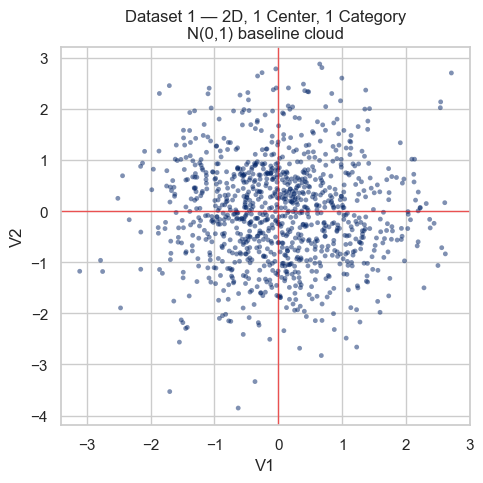

In [7]:
# Plot — mirrors R: plot(a, col=royalblue, xlab='V1', ylab='V2')
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(df1['V1'], df1['V2'],
           color=ROYALBLUE, s=12, alpha=0.5, edgecolors='none')
ax.axhline(0, color='red', linewidth=1, linestyle='-', alpha=0.6)  # abline(h=0)
ax.axvline(0, color='red', linewidth=1, linestyle='-', alpha=0.6)  # abline(v=0)
ax.set_xlabel('V1')
ax.set_ylabel('V2')
ax.set_title('Dataset 1 — 2D, 1 Center, 1 Category\nN(0,1) baseline cloud')
plt.tight_layout()
plt.show()

---

## Dataset 2: 2D, 2 Centers, 2 Categories (Linearly Separable)

Mirrors R:
```r
set.seed(1234321)
ab[1:(n/2), 1] <- ab[1:(n/2), 1] + ctr_positions   # cat0: center at +3
ab[beg:n,   1] <- ab[beg:n,   1] - ctr_positions   # cat1: center at -3
```

Two blobs offset ±`ctr_positions` along V1. `ctr_positions=3` here
(wider than the NN notebook's `ctr_positions=1`) for clear visual separation.

In [8]:
df2 = build_2d_2class(n=1000, ctr_positions=3, seed=1234321)

print(f'Dataset 2 — 2D, 2 centers, 2 categories')
print(f'  Shape         : {df2.shape}')
print(f'  Class balance : {df2["cl"].value_counts().sort_index().to_dict()}')
print(f'  cat0 V1 mean  : {df2[df2["cl"]==0]["V1"].mean():.3f}  (expected ≈ +3)')
print(f'  cat1 V1 mean  : {df2[df2["cl"]==1]["V1"].mean():.3f}  (expected ≈ -3)')

Dataset 2 — 2D, 2 centers, 2 categories
  Shape         : (1000, 3)
  Class balance : {0: 500, 1: 500}
  cat0 V1 mean  : 3.034  (expected ≈ +3)
  cat1 V1 mean  : -2.993  (expected ≈ -3)


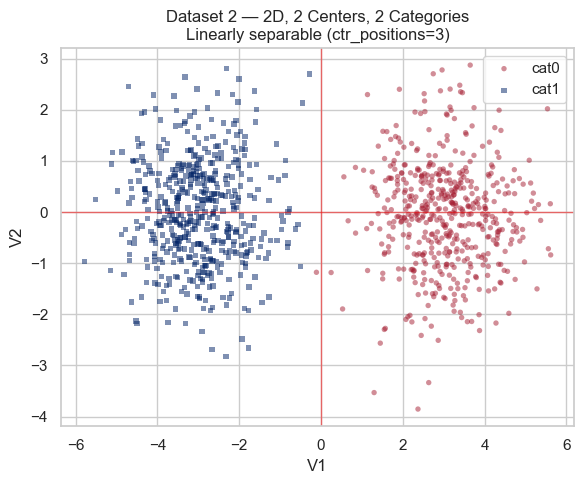

In [9]:
# Plot — mirrors R: plot(ab, col=as.numeric(factor(category)), pch=...)
fig, ax = plt.subplots(figsize=(6, 5))
palette = {0: CRIMSON, 1: ROYALBLUE}
markers = {0: 'o', 1: 's'}
for cl in [0, 1]:
    mask = df2['cl'] == cl
    ax.scatter(df2.loc[mask, 'V1'], df2.loc[mask, 'V2'],
               color=palette[cl], marker=markers[cl],
               s=15, alpha=0.5, edgecolors='none',
               label=f'cat{cl}')
ax.axhline(0, color='red', linewidth=1, linestyle='-', alpha=0.5)
ax.axvline(0, color='red', linewidth=1, linestyle='-', alpha=0.5)
ax.set_xlabel('V1')
ax.set_ylabel('V2')
ax.set_title('Dataset 2 — 2D, 2 Centers, 2 Categories\n'
             f'Linearly separable (ctr_positions=3)')
ax.legend()
plt.tight_layout()
plt.show()

---

## Dataset 3: 2D, 4 Centers, 2 Categories (XOR-like)

Mirrors R:
```r
set.seed(1234321)
ab_centers <- matrix(sample(c(-1,1)*2, n*4, replace=TRUE), ncol=2)
ab <- ab + ab_centers
category <- paste0('cat', (1 + sign(apply(ab_centers, 1, prod)))/2)
```

Centers at (±2, ±2). Same-sign quadrants → cat0; opposite-sign → cat1.
Classic XOR pattern — requires non-linear decision boundary.

In [10]:
df3 = build_2d_4class(n=1000, ctr_positions=2, seed=1234321)

print(f'Dataset 3 — 2D, 4 centers, 2 categories (XOR)')
print(f'  Shape         : {df3.shape}')
print(f'  Class balance : {df3["cl"].value_counts().sort_index().to_dict()}')
# Verify XOR pattern
for cl in [0, 1]:
    sub = df3[df3['cl'] == cl]
    print(f'  cat{cl} center_V1 unique: {sorted(sub["center_V1"].unique())}  '
          f'center_V2 unique: {sorted(sub["center_V2"].unique())}')

Dataset 3 — 2D, 4 centers, 2 categories (XOR)
  Shape         : (1000, 5)
  Class balance : {0: 465, 1: 535}
  cat0 center_V1 unique: [np.int64(-2), np.int64(2)]  center_V2 unique: [np.int64(-2), np.int64(2)]
  cat1 center_V1 unique: [np.int64(-2), np.int64(2)]  center_V2 unique: [np.int64(-2), np.int64(2)]


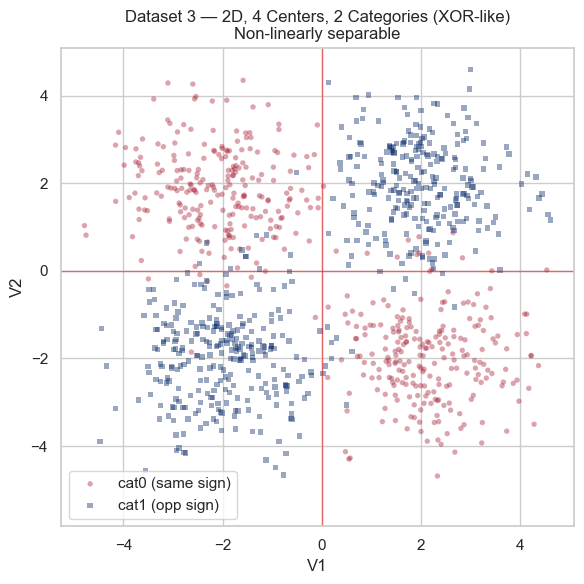

In [11]:
# Plot — mirrors R: plot(ab, col=as.numeric(factor(category)), pch=...)
fig, ax = plt.subplots(figsize=(6, 6))
for cl in [0, 1]:
    mask = df3['cl'] == cl
    ax.scatter(df3.loc[mask, 'V1'], df3.loc[mask, 'V2'],
               color=palette[cl], marker=markers[cl],
               s=15, alpha=0.4, edgecolors='none',
               label=f'cat{cl} ({"same sign" if cl==0 else "opp sign"})')
ax.axhline(0, color='red', linewidth=1, linestyle='-', alpha=0.5)
ax.axvline(0, color='red', linewidth=1, linestyle='-', alpha=0.5)
ax.set_xlabel('V1')
ax.set_ylabel('V2')
ax.set_title('Dataset 3 — 2D, 4 Centers, 2 Categories (XOR-like)\n'
             'Non-linearly separable')
ax.legend()
plt.tight_layout()
plt.show()

---

## Dataset 4: 3D, Cube Boundary, 2 Categories

Mirrors R:
```r
set.seed(123321)
xyz <- bld_3d_2c()   # n=1000, b=1.25
scatterplot3d(xyz[,2:4], color=colors, pch=xyz[,1])
cubedraw(plot3d, min=-1.25, max=1.25, cex=2)
```

Inside the cube [-1.25, 1.25]³ → class 0. Outside → class 1.
The wireframe cube shows the boundary explicitly.

In [12]:
df4 = build_3d_2class(n=1000, b=1.25, seed=123321)

print(f'Dataset 4 — 3D, cube boundary, 2 categories')
print(f'  Shape         : {df4.shape}')
print(f'  Class balance : {df4["cl"].value_counts().sort_index().to_dict()}')
print(f'  (cl=0: inside cube, cl=1: outside cube)')
print()
print(df4.describe().round(4))

Dataset 4 — 3D, cube boundary, 2 categories
  Shape         : (1000, 4)
  Class balance : {0: 468, 1: 532}
  (cl=0: inside cube, cl=1: outside cube)

              cl          x          y          z
count  1000.0000  1000.0000  1000.0000  1000.0000
mean      0.5320    -0.0619     0.1005     0.0035
std       0.4992     0.9854     1.0496     1.0022
min       0.0000    -2.9604    -3.5584    -3.5935
25%       0.0000    -0.7315    -0.5696    -0.6878
50%       1.0000    -0.0693     0.1226    -0.0124
75%       1.0000     0.6281     0.8305     0.6874
max       1.0000     3.1993     3.5483     2.8372


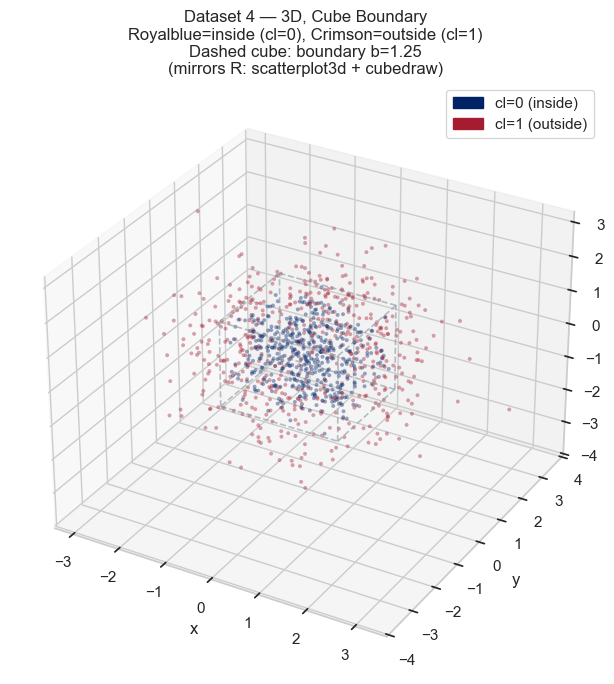

In [13]:
# 3D scatter + cube wireframe
# Mirrors R: scatterplot3d(...) + cubedraw(plot3d, min=-1.25, max=1.25)
fig = plt.figure(figsize=(8, 7))
ax  = fig.add_subplot(111, projection='3d')

colors_3d = [ROYALBLUE if c == 0 else CRIMSON for c in df4['cl']]
ax.scatter(df4['x'], df4['y'], df4['z'],
           c=colors_3d, s=8, alpha=0.4, edgecolors='none')

# Cube wireframe — mirrors R: cubedraw(plot3d, min=-1.25, max=1.25)
draw_cube_wireframe(ax, b=1.25, color=SLATE)

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_title('Dataset 4 — 3D, Cube Boundary\n'
             'Royalblue=inside (cl=0), Crimson=outside (cl=1)\n'
             'Dashed cube: boundary b=1.25\n'
             '(mirrors R: scatterplot3d + cubedraw)')

patch0 = mpatches.Patch(color=ROYALBLUE, label='cl=0 (inside)')
patch1 = mpatches.Patch(color=CRIMSON,   label='cl=1 (outside)')
ax.legend(handles=[patch0, patch1])
plt.tight_layout()
plt.show()

---

## Overview: All Four Datasets Side by Side

A single portfolio figure showing all four generators at a glance.
Not in the original R script — added here as a toolbox summary.

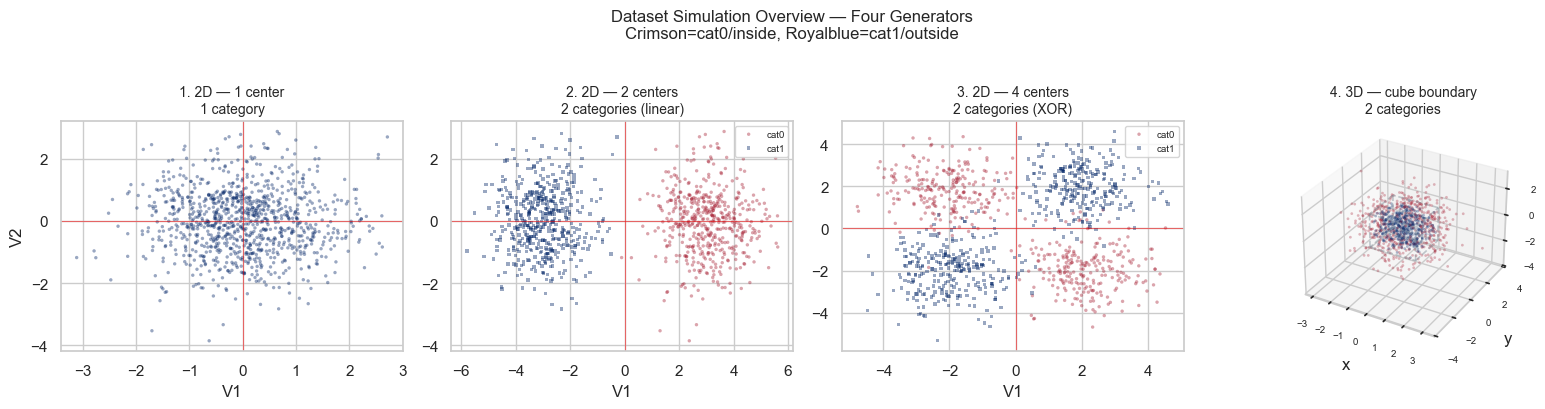

In [14]:
fig = plt.figure(figsize=(16, 4))

# Panel 1: 2D 1 class
ax1 = fig.add_subplot(141)
ax1.scatter(df1['V1'], df1['V2'], color=ROYALBLUE,
            s=6, alpha=0.4, edgecolors='none')
ax1.axhline(0, color='red', lw=0.8, alpha=0.5)
ax1.axvline(0, color='red', lw=0.8, alpha=0.5)
ax1.set_title('1. 2D — 1 center\n1 category', fontsize=10)
ax1.set_xlabel('V1'); ax1.set_ylabel('V2')

# Panel 2: 2D 2 class
ax2 = fig.add_subplot(142)
for cl in [0, 1]:
    mask = df2['cl'] == cl
    ax2.scatter(df2.loc[mask,'V1'], df2.loc[mask,'V2'],
                color=palette[cl], marker=markers[cl],
                s=6, alpha=0.4, edgecolors='none', label=f'cat{cl}')
ax2.axhline(0, color='red', lw=0.8, alpha=0.5)
ax2.axvline(0, color='red', lw=0.8, alpha=0.5)
ax2.set_title('2. 2D — 2 centers\n2 categories (linear)', fontsize=10)
ax2.set_xlabel('V1'); ax2.legend(fontsize=7)

# Panel 3: 2D 4 class XOR
ax3 = fig.add_subplot(143)
for cl in [0, 1]:
    mask = df3['cl'] == cl
    ax3.scatter(df3.loc[mask,'V1'], df3.loc[mask,'V2'],
                color=palette[cl], marker=markers[cl],
                s=6, alpha=0.4, edgecolors='none', label=f'cat{cl}')
ax3.axhline(0, color='red', lw=0.8, alpha=0.5)
ax3.axvline(0, color='red', lw=0.8, alpha=0.5)
ax3.set_title('3. 2D — 4 centers\n2 categories (XOR)', fontsize=10)
ax3.set_xlabel('V1'); ax3.legend(fontsize=7)

# Panel 4: 3D cube
ax4 = fig.add_subplot(144, projection='3d')
colors_3d = [ROYALBLUE if c == 0 else CRIMSON for c in df4['cl']]
ax4.scatter(df4['x'], df4['y'], df4['z'],
            c=colors_3d, s=4, alpha=0.3, edgecolors='none')
draw_cube_wireframe(ax4, b=1.25, color=SLATE, alpha=0.5)
ax4.set_title('4. 3D — cube boundary\n2 categories', fontsize=10)
ax4.set_xlabel('x'); ax4.set_ylabel('y'); ax4.set_zlabel('z')
ax4.tick_params(labelsize=7)

fig.suptitle('Dataset Simulation Overview — Four Generators\n'
             'Crimson=cat0/inside, Royalblue=cat1/outside',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

---

## DatasetSimulator — Quick Demo

In [15]:
# Convenience class demo
sim = DatasetSimulator(n=1000, seed=1234321)

_ = sim.get_2d_1class()
_ = sim.get_2d_2class(ctr_positions=3)
_ = sim.get_2d_4class(ctr_positions=2)
_ = sim.get_3d_2class(b=1.25)

print('DatasetSimulator summary:')
sim.summary()

DatasetSimulator summary:
  2d_1class      : shape=(1000, 3)  class balance={0: 1000}
  2d_2class      : shape=(1000, 3)  class balance={0: 500, 1: 500}
  2d_4class      : shape=(1000, 5)  class balance={0: 465, 1: 535}
  3d_2class      : shape=(1000, 4)  class balance={0: 468, 1: 532}


---

# Summary

## Key Takeaways

1. **Four canonical generators:** `build_2d_1class`, `build_2d_2class`,
   `build_2d_4class`, `build_3d_2class` — all return clean `pd.DataFrame`
   objects with a consistent `cl` column for class labels.

2. **Separation matters:** `ctr_positions=3` (this toolbox) vs `ctr_positions=1`
   (NN notebook) — the wider separation here makes the generator behavior
   visually obvious. Downstream notebooks use tighter separation for
   more realistic classification challenges.

3. **Vectorized cube check:** The R `bld_3d_2c()` function used a Python-equivalent
   of a for-loop to check each coordinate. The Python version uses
   `np.any(np.abs(xyz) > b, axis=1)` — a single vectorized operation,
   orders of magnitude faster.

4. **`DatasetSimulator`** provides a clean interface for generating
   multiple datasets with consistent seeds — useful for notebooks
   that need several datasets in sequence.

## R → Python Mapping

| R | Python |
|---|--------|
| `matrix(rnorm(n*2), ncol=2)` | `rng.normal(0, 1, size=(n, 2))` |
| `set.seed(1234321)` | `np.random.default_rng(seed=1234321)` |
| `bld_3d_2c(n, b)` | `build_3d_2class(n, b, seed)` |
| R for-loop coordinate check | `np.any(np.abs(xyz) > b, axis=1)` |
| `cbind(cl, xyz)` | `pd.DataFrame({'cl': cl, 'x':..., 'y':..., 'z':...})` |
| `paste0('cat', ...)` | `np.where(cl==0, 'cat0', 'cat1')` |
| `sign(apply(ab_centers, 1, prod))` | `np.sign(ab_centers[:,0] * ab_centers[:,1])` |
| `scatterplot3d(xyz[,2:4])` | `ax.scatter()` with `projection='3d'` |
| `cubedraw(plot3d, min=-b, max=b)` | `draw_cube_wireframe(ax, b=b)` |
| `plot(ab, col=..., pch=...)` | `ax.scatter(..., color=..., marker=...)` |
| `abline(h=0)`, `abline(v=0)` | `ax.axhline(0)`, `ax.axvline(0)` |

## References

1. Harvard Elements of Statistical Learning (2021), Dr. Andrey Sivachenko
   and Dr. Victor A. Farutin. Original `bld_3d_2c()` and dataset designs.
2. Martin Maechler. `cubedraw()` from `scatterplot3d` package documentation.
3. Gareth James, et al. *An Introduction to Statistical Learning with
   Applications in R*. Springer. ISBN 978-1-4614-7137-0.
4. James, G., Witten, D., Hastie, T., Tibshirani, R., Taylor, J.
   *An Introduction to Statistical Learning with Applications in Python*.
   Springer, 2023. https://www.statlearning.com